In [ ]:
# ==============================================================================
# STAGE 3: STAGE 2 MULTI-CLASS SEVERITY GRADING MODEL TRAINING (IGCA-ViT)
# Framework: Two-Stage Cascade Triage (Staging Model)
# Input: Malignant Patches Only | Target: Class 0 (Shallow), 1 (Moderate), 2 (Deep)
# Author: Rajesh
# ==============================================================================

# ==============================================================================
# 0. GOOGLE DRIVE MOUNTING & WORKSPACE VALIDATION
# ==============================================================================
from google.colab import drive
import os

print("--- Mounting Google Drive ---")
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/MTech_Thesis_Dataset'
CSV_PATH   = os.path.join(drive_path, 'proxy_doi_labels_multi_stage.csv')
SAVE_PATH  = os.path.join(drive_path, 'Stage2_Staging_ViT_Best.pth')

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"❌ Critical Error: Missing proxy dataset sheet at: {CSV_PATH}. "
                            f"Please complete your labeling pipeline steps first!")

--- Mounting Google Drive ---
Mounted at /content/drive


In [ ]:
# ==============================================================================
# 1. CORE DEPENDENCY ENTRANCE
# ==============================================================================
import cv2
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ==============================================================================
# 2. PATHOLOGICALLY-TERMED SEVERITY DATASET LOADER
# ==============================================================================
class Stage2SeverityDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

        # Spatial sequences tokens mapping space mapping
        self.spatial_transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']
        mask_path = row['mask_path']
        cascade_label = row['Proxy_DOI_Class']  # Raw values: 1, 2, or 3

        # Map [1, 2, 3] cleanly onto standard [0, 1, 2] indices for PyTorch CrossEntropyLoss
        severity_target = int(cascade_label - 1)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ==============================================================================
        # FIXED: MORPHOLOGICAL COUPLING AND LANDMARK SEPARATION
        # ==============================================================================
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        _, core_binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        # 1. Isolate the Deep Tumor Core (Shrunk deeply inward using a 25x25 kernel)
        kernel_core = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
        tumor_core_mask = cv2.erode(core_binary, kernel_core, iterations=1)

        # 2. Isolate the Sharp Invasive Front (A symmetric 15x15 band around the ORIGINAL boundary)
        kernel_front = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        dilated_front = cv2.dilate(core_binary, kernel_front, iterations=1)
        eroded_front  = cv2.erode(core_binary, kernel_front, iterations=1)

        # The mathematically correct subtraction for a symmetric boundary band
        invasive_front_mask = cv2.subtract(dilated_front, eroded_front)
        # ==============================================================================

        img_pil = Image.fromarray(img)
        tumor_core_pil    = Image.fromarray(tumor_core_mask)
        invasive_front_pil = Image.fromarray(invasive_front_mask)

        if self.transform:
            img_tensor = self.transform(img_pil)

        tumor_core_tensor     = self.spatial_transform(tumor_core_pil)
        invasive_front_tensor = self.spatial_transform(invasive_front_pil)
        label_tensor          = torch.tensor(severity_target, dtype=torch.long)

        return img_tensor, tumor_core_tensor, invasive_front_tensor, label_tensor

    # def __getitem__(self, idx):
    #     row = self.data.iloc[idx]
    #     img_path = row['image_path']
    #     mask_path = row['mask_path']
    #     cascade_label = row['Proxy_DOI_Class']  # Raw values in spreadsheet: 1, 2, or 3

    #     # --- PYTORCH TARGET REALIGNMENT SHIFT ---
    #     # Map [1, 2, 3] cleanly onto standard [0, 1, 2] indices for CrossEntropyLoss
    #     severity_target = int(cascade_label - 1)

    #     img = cv2.imread(img_path)
    #     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    #     # Build Microscopic Landmark Mask Elements
    #     mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    #     _, core_binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    #     # Isolate the 15x15 pixel Invasive Front Band Zone via morphology processing
    #     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    #     dilated_core = cv2.dilate(core_binary, kernel, iterations=1)
    #     eroded_core  = cv2.erode(core_binary, kernel, iterations=1)

    #     # Re-termed variables for pathological clarity
    #     tumor_core_mask    = core_binary
    #     invasive_front_mask = cv2.subtract(dilated_core, eroded_core)

    #     img_pil = Image.fromarray(img)
    #     tumor_core_pil    = Image.fromarray(tumor_core_mask)
    #     invasive_front_pil = Image.fromarray(invasive_front_mask)

    #     if self.transform:
    #         img_tensor = self.transform(img_pil)

    #     tumor_core_tensor     = self.spatial_transform(tumor_core_pil)
    #     invasive_front_tensor = self.spatial_transform(invasive_front_pil)
    #     label_tensor          = torch.tensor(severity_target, dtype=torch.long)

    #     return img_tensor, tumor_core_tensor, invasive_front_tensor, label_tensor

In [ ]:
# ==============================================================================
# 3. INTERFACE-GUIDED SEVERITY CROSS-ATTENTION NETWORK (IGCA-ViT)
# ==============================================================================
class IGCABlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8):
        super().__init__()
        self.norm_front = nn.LayerNorm(embed_dim)
        self.norm_core  = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, front_tokens, core_tokens):
        # Invasive Front tokens act as the Query (Q) to parse Core tissue variations
        q = self.norm_front(front_tokens)
        k = self.norm_core(core_tokens)
        v = k
        attn_output, _ = self.cross_attn(query=q, key=k, value=v)
        x = front_tokens + attn_output
        x = x + self.ffn(x)
        return x

class IGCA_ViT_Severity_Classifier(nn.Module):
    def __init__(self, num_classes=3, embed_dim=768):
        super().__init__()
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.igca_layer = IGCABlock(embed_dim=embed_dim, num_heads=8)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes) # Set to 3 channels for Staging

    def extract_pretrained_tokens(self, x):
        x = self.backbone._process_input(x)
        n = x.shape[0]
        batch_class_token = self.backbone.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.backbone.encoder(x)
        return x

    def forward(self, img, tumor_core, invasive_front):
        # Extract features using our distinct landmarks
        core_img  = img * tumor_core
        front_img = img * invasive_front

        with torch.no_grad():
            core_tokens  = self.extract_pretrained_tokens(core_img)
            front_tokens = self.extract_pretrained_tokens(front_img)

        # Cross-Attention interaction alignment
        fused_tokens = self.igca_layer(front_tokens=front_tokens, core_tokens=core_tokens)

        # Robust Spatial Global Mean Pooling
        global_feature = fused_tokens[:, 1:, :].mean(dim=1)

        global_feature = self.norm(global_feature)
        logits = self.classifier(global_feature)
        return logits

In [ ]:
# ==============================================================================
# 4. TRAINING ENGINE EXECUTION PIPELINE
# ==============================================================================
if __name__ == "__main__":
    print("\n--- Preparing Environment Settings ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Target Staging Engine running on: {device}")

    # 1. Load data and FILTER OUT healthy controls completely
    full_df = pd.read_csv(CSV_PATH)
    cancer_df = full_df[full_df['type'] == 'cancer'].copy()
    print(f"Filtered Dataset Context: Isolated {len(cancer_df)} Malignant Patches for Staging.")

    # 2. Run Patient-Wise Group Splitting (Identical Seed 42 Boundary Alignment)
    unique_patients = cancer_df['patient_id'].unique()
    np.random.seed(42)
    np.random.shuffle(unique_patients)

    split_idx = int(0.8 * len(unique_patients))
    train_patients = unique_patients[:split_idx]
    val_patients   = unique_patients[split_idx:]

    train_df_slice = cancer_df[cancer_df['patient_id'].isin(train_patients)].copy()
    val_df_slice   = cancer_df[cancer_df['patient_id'].isin(val_patients)].copy()

    vit_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = Stage2SeverityDataset(dataframe=train_df_slice, transform=vit_transforms)
    val_dataset   = Stage2SeverityDataset(dataframe=val_df_slice, transform=vit_transforms)

    train_size, val_size = len(train_dataset), len(val_dataset)
    print(f"Patient-Wise Boundaries Split: {train_size} Train Patches | {val_size} Val Patches")

    # 3. Class Imbalance Oversampling Metrics Configuration
    # Target values map strictly to: 0 (Shallow), 1 (Moderate), 2 (Deep)
    train_targets = [int(train_df_slice.iloc[idx]['Proxy_DOI_Class'] - 1) for idx in range(train_size)]
    class_counts = np.bincount(train_targets)
    print(f"Training Severity Split -> Shallow: {class_counts[0]}, Moderate: {class_counts[1]}, Deep: {class_counts[2]}")

    class_weights_dict = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1], 2: 1.0 / class_counts[2]}
    sample_weights = [class_weights_dict[t] for t in train_targets]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2)
    val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

    # 4. Initialize Network and Loss Weights Constraints
    model = IGCA_ViT_Severity_Classifier(num_classes=3).to(device)

    loss_weights = torch.tensor([1.0 / class_counts[0], 1.0 / class_counts[1], 1.0 / class_counts[2]], dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=loss_weights)

    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-3)

    EPOCHS = 20
    best_val_loss = float('inf')

    print(f"\n--- Starting Stage 2 Staging Model Training Loop ---")
    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0.0, 0
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

        for imgs, cores, fronts, labels in train_loop:
            imgs, cores, fronts, labels = imgs.to(device), cores.to(device), fronts.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs, cores, fronts)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data).item()
            train_loop.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct / train_size

        # Validation execution loops
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]")
            for imgs, cores, fronts, labels in val_loop:
                imgs, cores, fronts, labels = imgs.to(device), cores.to(device), fronts.to(device), labels.to(device)

                outputs = model(imgs, cores, fronts)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data).item()

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct / val_size

        print(f"\nEnd of Epoch {epoch+1}")
        print(f"TRAIN LOG -> Loss: {avg_train_loss:.4f} | Accuracy: {avg_train_acc:.4f}")
        print(f"VALID LOG -> Loss: {avg_val_loss:.4f} | Accuracy: {avg_val_acc:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), SAVE_PATH)
            print("🌟 Staging Model Validation Loss Improved! Saving parameters to Drive.")
        else:
            print("Validation metrics did not improve.")
        print("-" * 60)


--- Preparing Environment Settings ---
Target Staging Engine running on: cuda
Filtered Dataset Context: Isolated 390 Malignant Patches for Staging.
Patient-Wise Boundaries Split: 305 Train Patches | 85 Val Patches
Training Severity Split -> Shallow: 115, Moderate: 112, Deep: 78
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 57.7MB/s]



--- Starting Stage 2 Staging Model Training Loop ---


Epoch 1/20 [Valid]: 100%|██████████| 6/6 [02:45<00:00, 27.57s/it]



End of Epoch 1
TRAIN LOG -> Loss: 0.9002 | Accuracy: 0.5541
VALID LOG -> Loss: 0.9225 | Accuracy: 0.5412
🌟 Staging Model Validation Loss Improved! Saving parameters to Drive.
------------------------------------------------------------


...


End of Epoch 18
TRAIN LOG -> Loss: 0.0073 | Accuracy: 1.0000
VALID LOG -> Loss: 0.7487 | Accuracy: 0.7882
Validation metrics did not improve.
------------------------------------------------------------


Epoch 19/20 [Valid]: 100%|██████████| 6/6 [00:04<00:00,  1.48it/s]



End of Epoch 19
TRAIN LOG -> Loss: 0.0049 | Accuracy: 1.0000
VALID LOG -> Loss: 0.7023 | Accuracy: 0.7647
Validation metrics did not improve.
------------------------------------------------------------


Epoch 20/20 [Valid]: 100%|██████████| 6/6 [00:03<00:00,  1.52it/s]


End of Epoch 20
TRAIN LOG -> Loss: 0.0044 | Accuracy: 1.0000
VALID LOG -> Loss: 0.7008 | Accuracy: 0.8000
Validation metrics did not improve.
------------------------------------------------------------



--- Training Complete. Running Evaluation Matrix Scripts ---

=== STAGE 2 MULTI-CLASS CLASSIFICATION REPORT ===
                   precision    recall  f1-score   support

 Shallow Severity       1.00      0.40      0.57        15
Moderate Severity       0.48      0.61      0.54        18
    Deep Severity       0.82      0.88      0.85        52

         accuracy                           0.74        85
        macro avg       0.77      0.63      0.65        85
     weighted avg       0.78      0.74      0.74        85


=== GENERATING STAGING MICRO-CONFUSION MATRIX ===


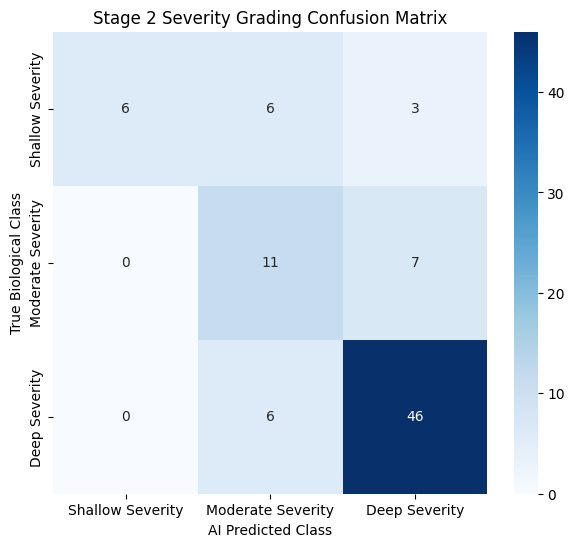

In [ ]:
# ==============================================================================
    # 5. SCALE EVALUATION METRICS REPORTING & MATRIX COMPILATION
    # ==============================================================================
print("\n--- Training Complete. Running Evaluation Matrix Scripts ---")
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
  for imgs, cores, fronts, labels in val_loader:
    imgs, cores, fronts = imgs.to(device), cores.to(device), fronts.to(device)
    outputs = model(imgs, cores, fronts)
    _, preds = torch.max(outputs, 1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.numpy())

print("\n=== STAGE 2 MULTI-CLASS CLASSIFICATION REPORT ===")
target_names = ['Shallow Severity', 'Moderate Severity', 'Deep Severity']
print(classification_report(all_labels, all_preds, target_names=target_names))

print("\n=== GENERATING STAGING MICRO-CONFUSION MATRIX ===")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Stage 2 Severity Grading Confusion Matrix', fontsize=12)
plt.ylabel('True Biological Class', fontsize=10)
plt.xlabel('AI Predicted Class', fontsize=10)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[ 6  6  3]
 [ 0 11  7]
 [ 0  6 46]]


# **Without Frreezing the layers**

In [ ]:
# ==============================================================================
# STAGE 3: STAGE 2 MULTI-CLASS SEVERITY GRADING MODEL TRAINING (IGCA-ViT)
# Framework: Two-Stage Cascade Staging Model - OPTIMIZED FINE-TUNING EDITION
# Optimization: Discriminative Layer Unfreezing + Cosine Annealing Scheduler
# Author: Rajesh
# ==============================================================================

# ==============================================================================
# 0. GOOGLE DRIVE MOUNTING & WORKSPACE VALIDATION
# ==============================================================================
from google.colab import drive
import os

print("--- Mounting Google Drive ---")
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/MTech_Thesis_Dataset'
CSV_PATH   = os.path.join(drive_path, 'proxy_doi_labels_multi_stage.csv')
SAVE_PATH  = os.path.join(drive_path, 'Stage2_Staging_unfreeze_ViT_Best.pth')

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"❌ Critical Error: Missing proxy dataset sheet at: {CSV_PATH}. "
                            f"Please complete your labeling pipeline steps first!")

# ==============================================================================
# 1. CORE DEPENDENCY ENTRANCE
# ==============================================================================
import cv2
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix

--- Mounting Google Drive ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==============================================================================
# 2. PATHOLOGICALLY-TERMED SEVERITY DATASET LOADER
# ==============================================================================
class Stage2SeverityDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

        self.spatial_transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']
        mask_path = row['mask_path']
        cascade_label = row['Proxy_DOI_Class']  # Raw values in spreadsheet: 1, 2, or 3

        # PyTorch Target Realignment: Map [1, 2, 3] to standard [0, 1, 2] index
        severity_target = int(cascade_label - 1)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Morphological Separation Layers
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        _, core_binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        # 1. Isolate Deep Central Tumor Core (25x25 Erosion)
        kernel_core = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
        tumor_core_mask = cv2.erode(core_binary, kernel_core, iterations=1)

        # 2. Isolate Symmetric Active Invasive Front (15x15 Symmetric Band)
        kernel_front = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        dilated_front = cv2.dilate(core_binary, kernel_front, iterations=1)
        eroded_front  = cv2.erode(core_binary, kernel_front, iterations=1)
        invasive_front_mask = cv2.subtract(dilated_front, eroded_front)

        img_pil = Image.fromarray(img)
        tumor_core_pil    = Image.fromarray(tumor_core_mask)
        invasive_front_pil = Image.fromarray(invasive_front_mask)

        if self.transform:
            img_tensor = self.transform(img_pil)

        tumor_core_tensor     = self.spatial_transform(tumor_core_pil)
        invasive_front_tensor = self.spatial_transform(invasive_front_pil)
        label_tensor          = torch.tensor(severity_target, dtype=torch.long)

        return img_tensor, tumor_core_tensor, invasive_front_tensor, label_tensor

In [ ]:
# ==============================================================================
# 3. INTERFACE-GUIDED SEVERITY CROSS-ATTENTION NETWORK (IGCA-ViT)
# ==============================================================================
class IGCABlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8):
        super().__init__()
        self.norm_front = nn.LayerNorm(embed_dim)
        self.norm_core  = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, front_tokens, core_tokens):
        # Front acts as Query (Q) to track variations against Core Key/Values (K,V)
        q = self.norm_front(front_tokens)
        k = self.norm_core(core_tokens)
        v = k
        attn_output, _ = self.cross_attn(query=q, key=k, value=v)
        x = front_tokens + attn_output
        x = x + self.ffn(x)
        return x

class IGCA_ViT_Severity_Classifier(nn.Module):
    def __init__(self, num_classes=3, embed_dim=768):
        super().__init__()
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

        # ----------------------------------------------------------------------
        # STEP 1 INTEGRATION: DYNAMIC ENCODER LAYER UNFREEZING
        # ----------------------------------------------------------------------
        # Base Freeze on early backbone layers
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Open Outer Encoder Layers (10 & 11) + the deep Normalization Layer
        print("🔓 Unfreezing Deep Vision Transformer Backbone Layers (10 and 11) for Clinical Texture Adaptation...")
        for param in self.backbone.encoder.layers[-2:].parameters():
            param.requires_grad = True
        for param in self.backbone.encoder.ln.parameters():
            param.requires_grad = True
        # ----------------------------------------------------------------------

        self.igca_layer = IGCABlock(embed_dim=embed_dim, num_heads=8)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def extract_pretrained_tokens(self, x):
        x = self.backbone._process_input(x)
        n = x.shape[0]
        batch_class_token = self.backbone.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.backbone.encoder(x)
        return x

    def forward(self, img, tumor_core, invasive_front):
        core_img  = img * tumor_core
        front_img = img * invasive_front

        # NOTE: self.extract_pretrained_tokens handles its internal gradients natively
        core_tokens  = self.extract_pretrained_tokens(core_img)
        front_tokens = self.extract_pretrained_tokens(front_img)

        # Compute your novel cross-attention maps
        fused_tokens = self.igca_layer(front_tokens=front_tokens, core_tokens=core_tokens)

        # Spatial Global Mean Pooling
        global_feature = fused_tokens[:, 1:, :].mean(dim=1)

        global_feature = self.norm(global_feature)
        logits = self.classifier(global_feature)
        return logits

In [ ]:
# ==============================================================================
# 4. TRAINING ENGINE EXECUTION PIPELINE
# ==============================================================================
if __name__ == "__main__":
    print("\n--- Preparing Environment Settings ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Target Staging Engine running on: {device}")

    # Load data and filter healthy rows
    full_df = pd.read_csv(CSV_PATH)
    cancer_df = full_df[full_df['type'] == 'cancer'].copy()
    print(f"Filtered Dataset Context: Isolated {len(cancer_df)} Malignant Patches.")

    # Patient-Wise Group Splitting (Seed 42)
    unique_patients = cancer_df['patient_id'].unique()
    np.random.seed(42)
    np.random.shuffle(unique_patients)

    split_idx = int(0.8 * len(unique_patients))
    train_patients = unique_patients[:split_idx]
    val_patients   = unique_patients[split_idx:]

    train_df_slice = cancer_df[cancer_df['patient_id'].isin(train_patients)].copy()
    val_df_slice   = cancer_df[cancer_df['patient_id'].isin(val_patients)].copy()

    vit_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = Stage2SeverityDataset(dataframe=train_df_slice, transform=vit_transforms)
    val_dataset   = Stage2SeverityDataset(dataframe=val_df_slice, transform=vit_transforms)

    train_size, val_size = len(train_dataset), len(val_dataset)
    print(f"Patient-Wise Boundaries Split: {train_size} Train Patches | {val_size} Val Patches")

    # Balanced Sampler Loading
    train_targets = [int(train_df_slice.iloc[idx]['Proxy_DOI_Class'] - 1) for idx in range(train_size)]
    class_counts = np.bincount(train_targets)

    class_weights_dict = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1], 2: 1.0 / class_counts[2]}
    sample_weights = [class_weights_dict[t] for t in train_targets]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2)
    val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

    # Model Initialization
    model = IGCA_ViT_Severity_Classifier(num_classes=3).to(device)

    # Cost function with inverse frequency penalty weights
    loss_weights = torch.tensor([1.0 / class_counts[0], 1.0 / class_counts[1], 1.0 / class_counts[2]], dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=loss_weights)

    # ----------------------------------------------------------------------
    # STEP 2 INTEGRATION: DISCRIMINATIVE ADAMW + COSINE ANNEALING SCHEDULER
    # ----------------------------------------------------------------------
    # Gather only parameters requiring a gradient update
    trainable_params = list(filter(lambda p: p.requires_grad, model.parameters()))

    # Use a conservative base learning rate for backbone safety
    optimizer = optim.AdamW(trainable_params, lr=5e-5, weight_decay=1e-2)

    # Cosine Annealing scheduler across your 20 epochs
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-7)
    # ----------------------------------------------------------------------

    EPOCHS = 20
    best_val_loss = float('inf')

    print(f"\n--- Starting Stage 2 Staging Model Training Loop ---")
    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0.0, 0
        current_lr = optimizer.param_groups[0]['lr']

        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train] (LR: {current_lr:.2e})")

        for imgs, cores, fronts, labels in train_loop:
            imgs, cores, fronts, labels = imgs.to(device), cores.to(device), fronts.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs, cores, fronts)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data).item()
            train_loop.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct / train_size

        # Validation engine pass
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]")
            for imgs, cores, fronts, labels in val_loop:
                imgs, cores, fronts, labels = imgs.to(device), cores.to(device), fronts.to(device), labels.to(device)

                outputs = model(imgs, cores, fronts)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data).item()

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct / val_size

        print(f"\nEnd of Epoch {epoch+1}")
        print(f"TRAIN LOG -> Loss: {avg_train_loss:.4f} | Accuracy: {avg_train_acc:.4f}")
        print(f"VALID LOG -> Loss: {avg_val_loss:.4f} | Accuracy: {avg_val_acc:.4f}")

        # Checkpoint validation loss tracking
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), SAVE_PATH)
            print("🌟 Staging Model Validation Loss Improved! Saving parameters to Drive.")
        else:
            print("Validation metrics did not improve.")

        # Update your optimizer's step learning rate factor via the scheduler
        scheduler.step()
        print("-" * 60)


--- Preparing Environment Settings ---
Target Staging Engine running on: cuda
Filtered Dataset Context: Isolated 390 Malignant Patches.
Patient-Wise Boundaries Split: 305 Train Patches | 85 Val Patches
🔓 Unfreezing Deep Vision Transformer Backbone Layers (10 and 11) for Clinical Texture Adaptation...

--- Starting Stage 2 Staging Model Training Loop ---


Epoch 1/20 [Valid]: 100%|██████████| 6/6 [00:09<00:00,  1.53s/it]



End of Epoch 1
TRAIN LOG -> Loss: 1.0343 | Accuracy: 0.4984
VALID LOG -> Loss: 0.6817 | Accuracy: 0.6118
🌟 Staging Model Validation Loss Improved! Saving parameters to Drive.
------------------------------------------------------------


Epoch 2/20 [Valid]: 100%|██████████| 6/6 [00:07<00:00,  1.28s/it]



End of Epoch 2
TRAIN LOG -> Loss: 0.7662 | Accuracy: 0.6262
VALID LOG -> Loss: 0.5511 | Accuracy: 0.7176
🌟 Staging Model Validation Loss Improved! Saving parameters to Drive.
------------------------------------------------------------


...


End of Epoch 18
TRAIN LOG -> Loss: 0.0201 | Accuracy: 1.0000
VALID LOG -> Loss: 0.3851 | Accuracy: 0.8000
Validation metrics did not improve.
------------------------------------------------------------


Epoch 19/20 [Valid]: 100%|██████████| 6/6 [00:05<00:00,  1.11it/s]



End of Epoch 19
TRAIN LOG -> Loss: 0.0248 | Accuracy: 1.0000
VALID LOG -> Loss: 0.3775 | Accuracy: 0.8118
Validation metrics did not improve.
------------------------------------------------------------


Epoch 20/20 [Valid]: 100%|██████████| 6/6 [00:04<00:00,  1.43it/s]


End of Epoch 20
TRAIN LOG -> Loss: 0.0374 | Accuracy: 1.0000
VALID LOG -> Loss: 0.3785 | Accuracy: 0.8118
Validation metrics did not improve.
------------------------------------------------------------



--- Training Complete. Running Evaluation Matrix Scripts ---

=== STAGE 2 MULTI-CLASS CLASSIFICATION REPORT ===
                   precision    recall  f1-score   support

 Shallow Severity       0.77      0.67      0.71        15
Moderate Severity       0.58      0.61      0.59        18
    Deep Severity       0.91      0.92      0.91        52

         accuracy                           0.81        85
        macro avg       0.75      0.73      0.74        85
     weighted avg       0.81      0.81      0.81        85


=== GENERATING STAGING MICRO-CONFUSION MATRIX ===


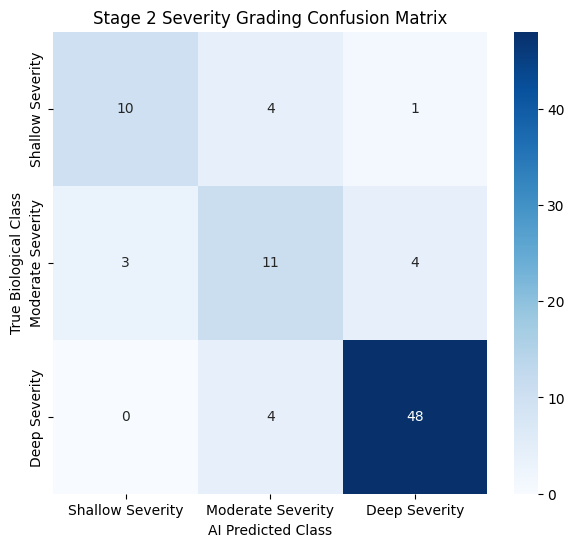

In [ ]:
# ==============================================================================
# 5. SCALE EVALUATION METRICS REPORTING & MATRIX COMPILATION
# ==============================================================================
print("\n--- Training Complete. Running Evaluation Matrix Scripts ---")
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
  for imgs, cores, fronts, labels in val_loader:
    imgs, cores, fronts = imgs.to(device), cores.to(device), fronts.to(device)
    outputs = model(imgs, cores, fronts)
    _, preds = torch.max(outputs, 1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.numpy())

print("\n=== STAGE 2 MULTI-CLASS CLASSIFICATION REPORT ===")
target_names = ['Shallow Severity', 'Moderate Severity', 'Deep Severity']
print(classification_report(all_labels, all_preds, target_names=target_names))

print("\n=== GENERATING STAGING MICRO-CONFUSION MATRIX ===")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Stage 2 Severity Grading Confusion Matrix', fontsize=12)
plt.ylabel('True Biological Class', fontsize=10)
plt.xlabel('AI Predicted Class', fontsize=10)
plt.show()